In [57]:
from pathlib import Path
import joblib

import pandas as pd
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
import seaborn as sns
from matplotlib import pyplot as plt


from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, recall_score

### Load data

In [77]:
# Load the training dataset used for model development.
work_data = pd.read_csv('../data/processed/train_data.csv')

# Load the independent validation dataset used for final model evaluation.
val_data = pd.read_csv('../data/processed/validation_data.csv')

In [78]:
# Separate the input features from the target variable.
X = work_data.drop(columns=['diabetes'])

# Extract the target variable for model training.
y = work_data['diabetes']

### Split data

In [79]:
# Split the working dataset into training and test sets.
# Stratify is used to preserve the original class distribution in both sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

### Initiate base model
---
Initialize the model with a minimal set of parameters to establish a baseline before hyperparameter tuning.

In [80]:
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.01,
    depth=6,
    class_weights=[1, 4],
    eval_metric='Recall',
    random_seed=42,
    verbose=False
)

model.fit(X_train, y_train)

In [81]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.96


In [82]:
# Show full classification report.
print("\nClassification Report CatBoost:")
print(classification_report(y_test, y_pred))


Classification Report CatBoost:
              precision    recall  f1-score   support

         0.0       0.98      0.97      0.98     14640
         1.0       0.74      0.80      0.77      1360

    accuracy                           0.96     16000
   macro avg       0.86      0.89      0.87     16000
weighted avg       0.96      0.96      0.96     16000



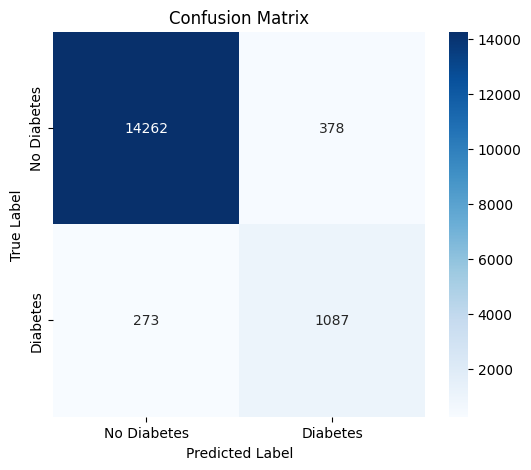

In [83]:
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

# Save the figure
plt.savefig('../reports/figures/experiment_3_025_th.png',
            dpi=300,
            bbox_inches='tight')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

### Initiate model and prepare for tuning

In [84]:
catboost_model = CatBoostClassifier(
    eval_metric='Recall',
    random_seed=42,
    verbose=False
)

In [85]:
# Parameters for tuning
param_grid = {
    "iterations": [300, 500, 700],
    "learning_rate": [0.01, 0.03, 0.05],
    "depth": [4, 6, 8],
    "class_weights": [
        [1, 2],
        [1, 3],
        [1, 4],
        [1, 5]
    ],
    "l2_leaf_reg": [1, 3, 5, 7]
}

In [86]:
# Set the grid search
grid_search = GridSearchCV(
    estimator=catboost_model,
    param_grid=param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1,
    verbose=2
)

In [50]:
grid_search.fit(X_train, y_train)
best_catboost_model = grid_search.best_estimator_

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


### Save the best performed model

In [87]:
models_path = Path("../models")
# Save the trained model to disk so it can be loaded later without retraining.
joblib.dump(best_catboost_model, models_path / "best_catboost_model.pkl")

['..\\models\\best_catboost_model.pkl']

In [88]:
y_pred = best_catboost_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9496875
Recall: 0.8286764705882353

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.96      0.97     14640
         1.0       0.66      0.83      0.74      1360

    accuracy                           0.95     16000
   macro avg       0.82      0.89      0.85     16000
weighted avg       0.96      0.95      0.95     16000


Confusion Matrix:
[[14068   572]
 [  233  1127]]


### Testing the model with validation data

In [53]:
val_data_test = val_data.copy()

In [54]:
attr = val_data_test.drop(columns=['diabetes'])
targ = val_data_test['diabetes']

In [58]:
catboost_model_x = joblib.load(
    models_path / "random_forest_experiment_3.pkl"
)

In [60]:
cb_pred = catboost_model_x.predict(attr)

In [61]:
print("Accuracy:", accuracy_score(targ, cb_pred))
print("Recall:", recall_score(targ, cb_pred))

print("\nClassification Report:")
print(classification_report(targ, cb_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(targ, cb_pred))

Accuracy: 0.972
Recall: 0.6841176470588235

Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98     18300
         1.0       0.98      0.68      0.81      1700

    accuracy                           0.97     20000
   macro avg       0.98      0.84      0.90     20000
weighted avg       0.97      0.97      0.97     20000


Confusion Matrix:
[[18277    23]
 [  537  1163]]


### Compare the results with test data and validation data.

In [89]:
compare_results = pd.DataFrame({
    ('CatBoost_Test_data', 'Class 0'): [0.98, 0.96, 0.97, 14640],
    ('CatBoost_Test_data', 'Class 1'): [0.66, 0.83, 0.74, 1360],
    ('CatBoost_Val_data', 'Class 0'): [0.97, 1.00, 0.98, 18300],
    ('CatBoost_Val_data', 'Class 1'): [0.98, 0.68, 0.81, 1700],
},
index=['Precision', 'Recall', 'F1-score', 'Support'])

compare_results.T

Precision  Recall  F1-score  Support
CatBoost_Test_data Class 0       0.98    0.96      0.97  14640.0
                   Class 1       0.66    0.83      0.74   1360.0
CatBoost_Val_data  Class 0       0.97    1.00      0.98  18300.0
                   Class 1       0.98    0.68      0.81   1700.0

**Note: Here, we take into account the fact that the number of observations differs between the two datasets when comparing the results.**

Model Comparison

The CatBoost model was evaluated on both the validation and test datasets.

On the validation dataset, the model achieved high Precision (0.98) for the diabetes class, meaning that most predicted diabetes cases were correct. However, its Recall was only 0.68, so about 32% of diabetic patients were missed.

On the test dataset, Recall increased to 0.83, meaning the model detected more diabetic patients. The trade-off was a lower Precision (0.66), resulting in more false positive predictions.

Conclusion

The results show the expected trade-off between Precision and Recall. Since the main goal of this project is to detect as many diabetic patients as possible and minimize false negatives, the test evaluation is preferred. Although it produces more false positives, it identifies a much larger proportion of patients with diabetes, which is more important for this type of medical prediction task.